<a href="https://colab.research.google.com/github/Avinash01715/ds-ml-projects/blob/main/Project_01/CarDekho_Used_Car_Price_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [562]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [563]:
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


# **EDA**

In [564]:
print("df.head()\n", df.head())
print("==" * 30)
print("df.shape\n",df.shape)
print("==" * 30)
print("df.info()\n",df.info())
print("==" * 30)
print("df.describe()\n",df.describe())
print("==" * 30)
print("missing values:\n",df.isnull().sum())

df.head()
                        name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  
df.shape
 (4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   s

In [565]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

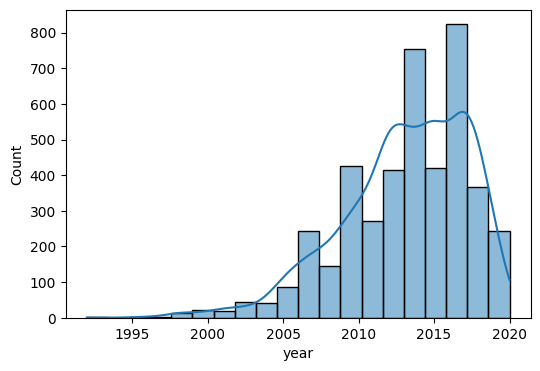

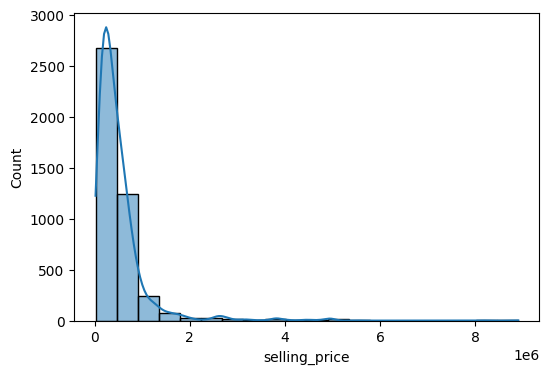

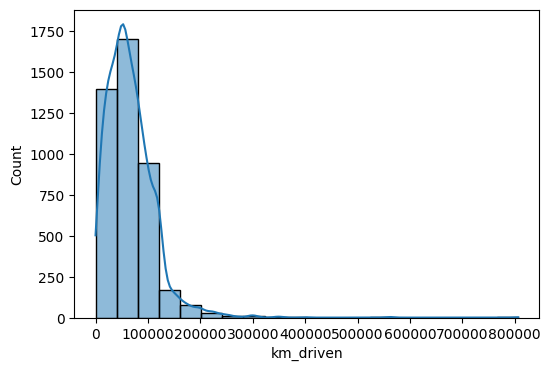

In [566]:
numeric_columns = ['year', 'selling_price', 'km_driven']
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde= True, bins = 20)

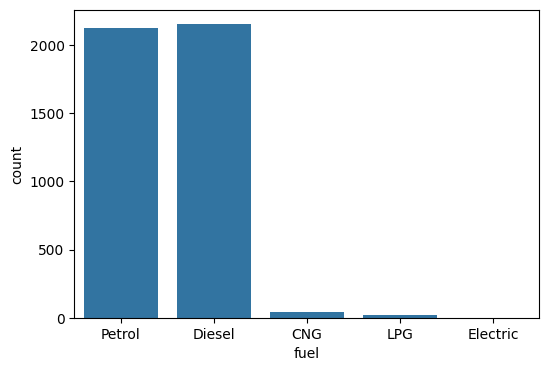

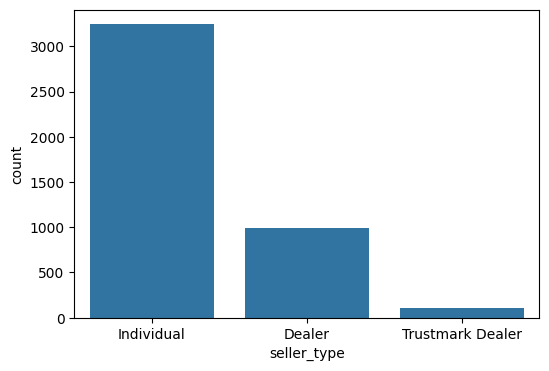

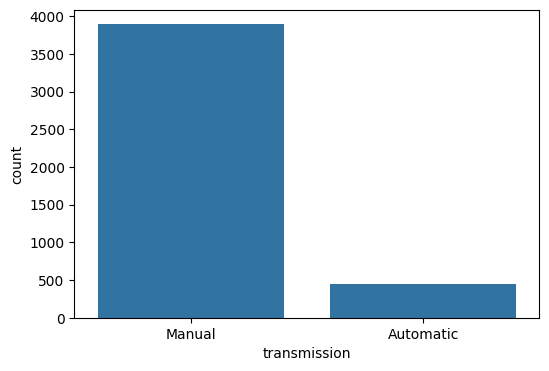

In [567]:
non_numeric_col = ['fuel', 'seller_type','transmission']
for cols in non_numeric_col:
  plt.figure(figsize = (6,4))
  sns.countplot(x = df[cols])

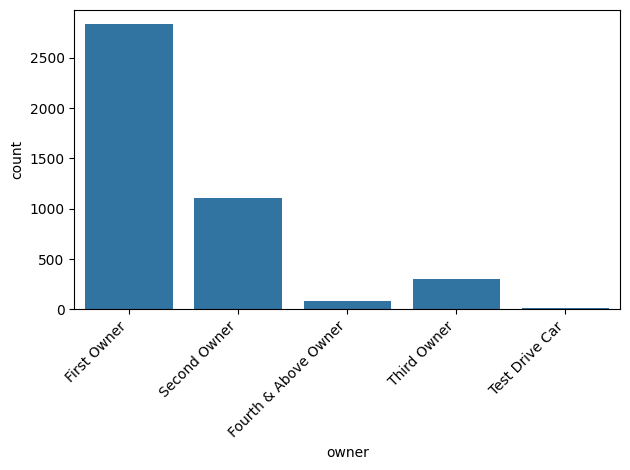

In [568]:
sns.countplot(x=df['owner'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

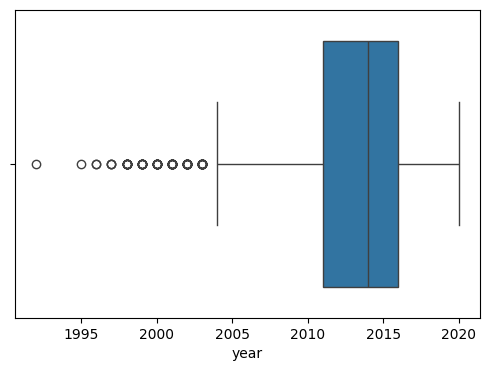

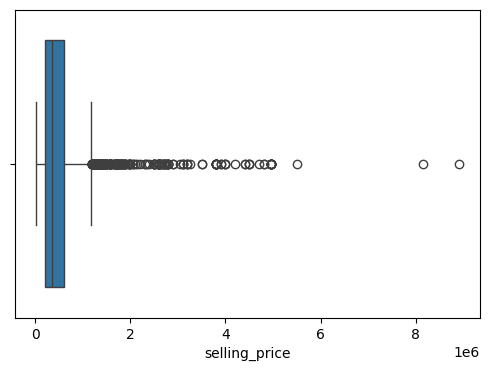

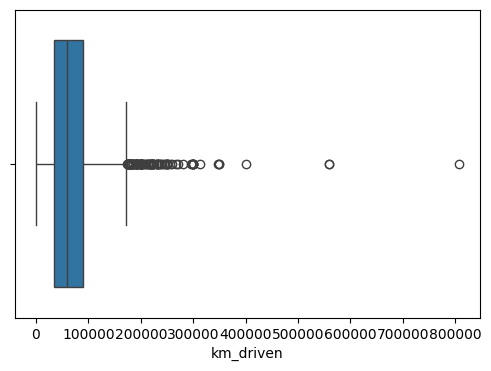

In [569]:
for cols in numeric_columns:
  plt.figure(figsize = (6,4))
  sns.boxplot(x = df[cols])

<Axes: >

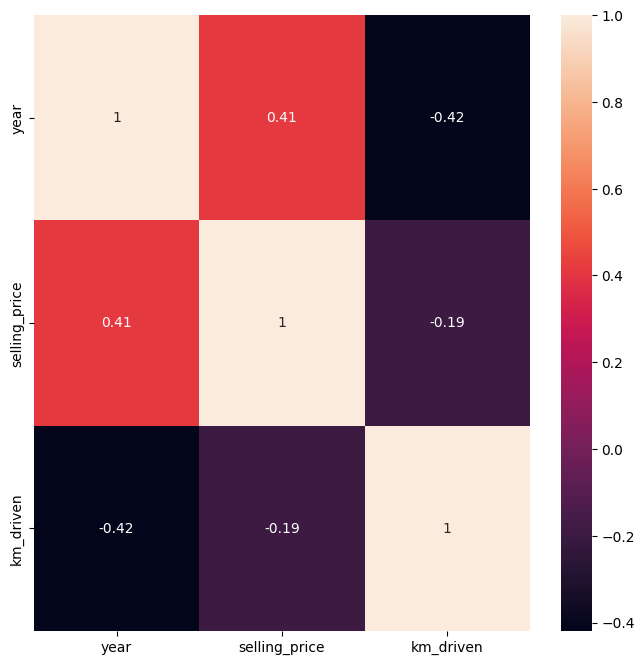

In [570]:
plt.figure(figsize = (8,8))
sns.heatmap(df.corr(numeric_only= True), annot= True)

# **DATA CLEANING AND PREPROCESSING**

In [571]:
df_clean = df.copy()
df_clean

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [572]:
df_clean.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [573]:
print("Before: ",df_clean.shape)

df_clean.drop_duplicates(inplace= True)

print("After: ",df_clean.shape)

Before:  (4340, 8)
After:  (3577, 8)


In [574]:
df_clean.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object


In [575]:
#One hot encoding
df_clean['fuel'].value_counts()

,count
fuel,
Diesel,1800
Petrol,1717
CNG,37
LPG,22
Electric,1


In [576]:
df_clean = pd.get_dummies(df_clean,columns= ['fuel'], drop_first=True)
df_clean.head()

,name,year,selling_price,km_driven,seller_type,transmission,owner,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol
0,Maruti 800 AC,2007,60000,70000,Individual,Manual,First Owner,False,False,False,True
1,Maruti Wagon R LXI Minor,2007,135000,50000,Individual,Manual,First Owner,False,False,False,True
2,Hyundai Verna 1.6 SX,2012,600000,100000,Individual,Manual,First Owner,True,False,False,False
3,Datsun RediGO T Option,2017,250000,46000,Individual,Manual,First Owner,False,False,False,True
4,Honda Amaze VX i-DTEC,2014,450000,141000,Individual,Manual,Second Owner,True,False,False,False


In [577]:
#One hot encoding
df_clean['seller_type'].value_counts()

,count
seller_type,
Individual,2832
Dealer,712
Trustmark Dealer,33


In [578]:
df_clean = pd.get_dummies(df_clean,columns= ['seller_type'], drop_first=True)
df_clean.head()

,name,year,selling_price,km_driven,transmission,owner,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,Maruti 800 AC,2007,60000,70000,Manual,First Owner,False,False,False,True,True,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,Manual,First Owner,False,False,False,True,True,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,Manual,First Owner,True,False,False,False,True,False
3,Datsun RediGO T Option,2017,250000,46000,Manual,First Owner,False,False,False,True,True,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,Manual,Second Owner,True,False,False,False,True,False


In [579]:
#One hot encoding
df_clean['transmission'].value_counts()

,count
transmission,
Manual,3265
Automatic,312


In [580]:
df_clean = pd.get_dummies(df_clean,columns= ['transmission'], drop_first=True)
df_clean.head()

,name,year,selling_price,km_driven,owner,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,Maruti 800 AC,2007,60000,70000,First Owner,False,False,False,True,True,False,True
1,Maruti Wagon R LXI Minor,2007,135000,50000,First Owner,False,False,False,True,True,False,True
2,Hyundai Verna 1.6 SX,2012,600000,100000,First Owner,True,False,False,False,True,False,True
3,Datsun RediGO T Option,2017,250000,46000,First Owner,False,False,False,True,True,False,True
4,Honda Amaze VX i-DTEC,2014,450000,141000,Second Owner,True,False,False,False,True,False,True


In [581]:
#One hot encoding
df_clean['owner'].value_counts()

,count
owner,
First Owner,2218
Second Owner,978
Third Owner,289
Fourth & Above Owner,75
Test Drive Car,17


In [582]:
df_clean = pd.get_dummies(df_clean,columns= ['owner'], drop_first=True)
df_clean.head()

,name,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti 800 AC,2007,60000,70000,False,False,False,True,True,False,True,False,False,False,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,False,False,False,True,True,False,True,False,False,False,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,True,False,False,False,True,False,True,False,False,False,False
3,Datsun RediGO T Option,2017,250000,46000,False,False,False,True,True,False,True,False,False,False,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,True,False,False,False,True,False,True,False,True,False,False


In [583]:
# Extract the first word as brand
df_clean['brand'] = df_clean['name'].str.split().str[0]

# Check the brands
print(df_clean['brand'].value_counts())

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Mitsubishi          5
Jaguar              5
Land                5
Volvo               4
Jeep                3
Ambassador          3
OpelCorsa           2
MG                  2
Force               1
Daewoo              1
Isuzu               1
Kia                 1
Name: count, dtype: int64


In [584]:
# Keep only top brands, group the rest as 'Other'
top_brands = df_clean['brand'].value_counts().nlargest(10).index

df_clean['brand'] = df_clean['brand'].apply(lambda x: x if x in top_brands else 'other')
df_clean.head()

,name,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,brand
0,Maruti 800 AC,2007,60000,70000,False,False,False,True,True,False,True,False,False,False,False,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,False,False,False,True,True,False,True,False,False,False,False,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,True,False,False,False,True,False,True,False,False,False,False,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,False,False,False,True,True,False,True,False,False,False,False,other
4,Honda Amaze VX i-DTEC,2014,450000,141000,True,False,False,False,True,False,True,False,True,False,False,Honda


In [585]:
brand_dummies = pd.get_dummies(df_clean['brand'], prefix='brand', drop_first=True)

# Drop one category to avoid dummy variable trap
brand_dummies = brand_dummies.drop(columns=['brand_other'])

# Add to your dataframe
df_clean = pd.concat([df_clean, brand_dummies], axis=1)
df_clean.head()

,name,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,brand,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen
0,Maruti 800 AC,2007,60000,70000,False,False,False,True,True,False,...,Maruti,False,False,False,False,True,False,False,False,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,False,False,False,True,True,False,...,Maruti,False,False,False,False,True,False,False,False,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,True,False,False,False,True,False,...,Hyundai,False,False,True,False,False,False,False,False,False
3,Datsun RediGO T Option,2017,250000,46000,False,False,False,True,True,False,...,other,False,False,False,False,False,False,False,False,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,True,False,False,False,True,False,...,Honda,False,True,False,False,False,False,False,False,False


In [586]:
df_clean.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel_Diesel',
       'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner', 'brand', 'brand_Ford',
       'brand_Honda', 'brand_Hyundai', 'brand_Mahindra', 'brand_Maruti',
       'brand_Renault', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen'],
      dtype='object')

In [587]:
df_clean = df_clean.astype({col: int for col in df_clean.columns if col not in ('name', 'brand')})
df_clean.head()

,name,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,brand,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen
0,Maruti 800 AC,2007,60000,70000,0,0,0,1,1,0,...,Maruti,0,0,0,0,1,0,0,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,0,0,1,1,0,...,Maruti,0,0,0,0,1,0,0,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,0,0,0,1,0,...,Hyundai,0,0,1,0,0,0,0,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,0,0,1,1,0,...,other,0,0,0,0,0,0,0,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,0,0,0,1,0,...,Honda,0,1,0,0,0,0,0,0,0


# **Feature extraction and engineering**

In [588]:
df_clean.describe()

,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,owner_Third Owner,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen
count,3577.000000,3.577000e+03,3577.000000,3577.000000,3577.00000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,...,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000
mean,2012.962538,4.739125e+05,69250.545709,0.503215,0.00028,0.006150,0.480011,0.791725,0.009226,0.912776,...,0.080794,0.061504,0.060386,0.178082,0.091697,0.299692,0.030752,0.086106,0.047526,0.025999
std,4.251759,5.093018e+05,47579.940016,0.500060,0.01672,0.078194,0.499670,0.406131,0.095619,0.282202,...,0.272557,0.240286,0.238234,0.382635,0.288638,0.458187,0.172669,0.280559,0.212791,0.159156
min,1992.000000,2.000000e+04,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010.000000,2.000000e+05,36000.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2013.000000,3.500000e+05,60000.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2016.000000,6.000000e+05,90000.000000,1.000000,0.00000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2020.000000,8.900000e+06,806599.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [589]:
# car's age as per 2026
df_clean['age'] = 2026 - df_clean['year']

# Log-transform km_driven ------> km_driven is right skewed
df_clean['km_driven_log'] = np.log1p(df_clean['km_driven'])

#  Usage intensity
df_clean['km_per_year'] = df_clean['km_driven'] / df_clean['age'].replace(0, 1)

df_clean['selling_price_log'] = np.log1p(df_clean['selling_price'])      #------> it is also right skewed and now it is our target variable

df_clean.head()

,name,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,brand_Mahindra,brand_Maruti,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen,age,km_driven_log,km_per_year,selling_price_log
0,Maruti 800 AC,2007,60000,70000,0,0,0,1,1,0,...,0,1,0,0,0,0,19,11.156265,3684.210526,11.002117
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,0,0,1,1,0,...,0,1,0,0,0,0,19,10.819798,2631.578947,11.813037
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,0,0,0,1,0,...,0,0,0,0,0,0,14,11.512935,7142.857143,13.304687
3,Datsun RediGO T Option,2017,250000,46000,0,0,0,1,1,0,...,0,0,0,0,0,0,9,10.736418,5111.111111,12.429220
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,0,0,0,1,0,...,0,0,0,0,0,0,12,11.856522,11750.000000,13.017005


In [590]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
col = ['km_driven_log', 'age', 'km_per_year']
scaler = StandardScaler()

df_clean[col] = scaler.fit_transform(df_clean[col])
df_clean.head()

,name,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,brand_Mahindra,brand_Maruti,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen,age,km_driven_log,km_per_year,selling_price_log
0,Maruti 800 AC,2007,60000,70000,0,0,0,1,1,0,...,0,1,0,0,0,0,1.402566,0.322989,-0.472689,11.002117
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,0,0,1,1,0,...,0,1,0,0,0,0,1.402566,-0.055156,-0.790278,11.813037
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,0,0,0,1,0,...,0,0,0,0,0,0,0.226418,0.723841,0.570820,13.304687
3,Datsun RediGO T Option,2017,250000,46000,0,0,0,1,1,0,...,0,0,0,0,0,0,-0.949731,-0.148864,-0.042179,12.429220
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,0,0,0,1,0,...,0,0,0,0,0,0,-0.244042,1.109988,1.960841,13.017005


In [591]:
df_clean.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel_Diesel',
       'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner', 'brand', 'brand_Ford',
       'brand_Honda', 'brand_Hyundai', 'brand_Mahindra', 'brand_Maruti',
       'brand_Renault', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen',
       'age', 'km_driven_log', 'km_per_year', 'selling_price_log'],
      dtype='object')

In [592]:
#--->drop columns
cols_to_drop = [
    'name',
    'selling_price',
    'year',
    'brand'
]

df_clean = df_clean.drop(columns=cols_to_drop)

In [593]:
df_clean.columns

Index(['km_driven', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra',
       'brand_Maruti', 'brand_Renault', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'age', 'km_driven_log', 'km_per_year',
       'selling_price_log'],
      dtype='object')

*pearsonr correlation calculation*

In [594]:
from scipy.stats import pearsonr


# list of features to be checked against target
selected_features = ['km_driven', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra',
       'brand_Maruti', 'brand_Renault', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'age', 'km_driven_log', 'km_per_year']

correlation = {
    feature: pearsonr(df_clean[feature],df_clean['selling_price_log'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlation.items()), columns=['features','pearson_correlation'])
correlation_df.sort_values(by = 'pearson_correlation', ascending=False)


,features,pearson_correlation
1,fuel_Diesel,0.382095
19,brand_Toyota,0.183297
15,brand_Mahindra,0.143080
13,brand_Honda,0.100859
6,seller_type_Trustmark Dealer,0.089979
10,owner_Test Drive Car,0.084989
12,brand_Ford,0.064890
20,brand_Volkswagen,0.041458
23,km_per_year,0.030954
17,brand_Renault,0.027255


In [595]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 1. Create the feature matrix X
features = [
  'km_driven', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra',
       'brand_Maruti', 'brand_Renault', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'age', 'km_driven_log', 'km_per_year'
]

X = df_clean[features].copy()

# 2. VIF Test
vif_results = {}

for i, col in enumerate(X.columns):
    vif_value = variance_inflation_factor(X.values, i)

    if vif_value > 10:
        decision = 'High Multicollinearity (Consider Dropping)'
    elif vif_value > 5:
        decision = 'Moderate Multicollinearity (Investigate)'
    else:
        decision = 'Low Multicollinearity (Keep)'

    vif_results[col] = {
        'VIF': vif_value,
        'Decision': decision
    }

vif_df = pd.DataFrame(vif_results).T
vif_df['VIF'] = vif_df['VIF'].astype(float)
vif_df = vif_df.sort_values(by='VIF', ascending=False)
vif_df

,VIF,Decision
km_driven,39.830542,High Multicollinearity (Consider Dropping)
fuel_Diesel,17.980339,High Multicollinearity (Consider Dropping)
fuel_Petrol,17.596458,High Multicollinearity (Consider Dropping)
km_per_year,13.750499,High Multicollinearity (Consider Dropping)
transmission_Manual,12.230670,High Multicollinearity (Consider Dropping)
seller_type_Individual,5.708495,Moderate Multicollinearity (Investigate)
km_driven_log,4.479957,Low Multicollinearity (Keep)
age,3.955124,Low Multicollinearity (Keep)
brand_Maruti,3.793360,Low Multicollinearity (Keep)
brand_Hyundai,2.647291,Low Multicollinearity (Keep)


In [596]:
df_clean.columns

Index(['km_driven', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra',
       'brand_Maruti', 'brand_Renault', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'age', 'km_driven_log', 'km_per_year',
       'selling_price_log'],
      dtype='object')

In [597]:
final_features = [

    'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner',
       'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra',
       'brand_Maruti', 'brand_Renault', 'brand_Tata', 'brand_Toyota',
       'brand_Volkswagen', 'age', 'km_driven_log'
]

final_df = df_clean[final_features + ['selling_price_log']]
final_df

,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,...,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen,age,km_driven_log,selling_price_log
0,0,0,0,1,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1.402566,0.322989,11.002117
1,0,0,0,1,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1.402566,-0.055156,11.813037
2,1,0,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0.226418,0.723841,13.304687
3,0,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,0,0,-0.949731,-0.148864,12.429220
4,1,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,-0.244042,1.109988,13.017005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,1,0,0,0,1,0,1,0,1,0,...,1,0,0,0,0,0,0,-0.244042,0.473059,12.923912
4336,1,0,0,0,1,0,1,0,1,0,...,1,0,0,0,0,0,0,-0.244042,0.473059,12.923912
4337,0,0,0,1,1,0,1,0,1,0,...,0,0,1,0,0,0,0,0.932107,0.514433,11.608245
4338,1,0,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,-0.714501,0.605430,13.670486


# **Model building**

**Spliting the data** into 80 / 20 - train and test data

In [598]:
from sklearn.model_selection import train_test_split

X = final_df.drop('selling_price_log', axis = 1)
y = final_df['selling_price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

**Creating linear regression model** -and fitting (training) data into it to train the model

In [599]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

Model Evaluation using r2 and adjusted_ r2

In [600]:
# comparing y_predictions with y_test
y_predictions = model.predict(X_test)

In [601]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_predictions)
print("R² Score:", r2)

n = X_test.shape[0]          #---> number of rows in X_test
p = X_test.shape[1]          #---> number of features in X_test

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("Adjusted R²:", adj_r2)

# Converting log predictions back to original price
y_predictions_original = np.expm1(y_predictions)
y_test_original = np.expm1(y_test)



R² Score: 0.7356129315453329
Adjusted R²: 0.7272196912769309
